# **W4 Text Classification (News Category) — v002**

**Module:** BC3415 Artificial Intelligence in Accounting & Finance
**Workshop:** Week 5 — Text / NLP · **Task:** Option 2 — configure, run and improve `WS_Colab_Text`
**Dataset:** `News Category (Text).csv` — HuffPost headlines labelled `COMEDY` / `CRIME`
**Evaluation criteria:** quality of the **data pre-processing**, and the **F1 score** achieved.

---

### What this notebook adds to `v001`

`v001` (the workshop notebook) loads the raw `headline` column, feeds it straight into
`CountVectorizer`, then `TfidfTransformer`, then BERT embeddings, and prints accuracy.
This version keeps that structure and those teaching sections, and extends them:

| Area | `v001` | `v002` (this notebook) |
|---|---|---|
| Runs where | Colab only (`drive.mount`, hard-coded Drive path) | Colab **and** locally — the loader detects its environment |
| Pre-processing | none — raw `headline` | 5-stage cleaning pipeline **plus an ablation that measures each stage** |
| Text used | `headline` only | `headline` + `short_description`, justified by the ablation |
| Duplicates | not handled | 14 duplicated stories removed *before* the split |
| Metric | accuracy, computed by hand from the confusion matrix | **macro-F1** (the graded metric), plus per-class precision / recall |
| Validation | one random `train_test_split` | stratified 5-fold cross-validation **and** a held-out test set |
| Models | LogisticRegression | LogReg, LinearSVC, ComplementNB, SGD, XGBoost, and a soft-voting ensemble |
| Reproducibility | no seed | `RANDOM_STATE = 42` throughout |
| Output | printed numbers | a saved `joblib` pipeline and a `predict_category()` function |

Two defects in `v001` are also corrected. Both are documented where they occur
(Sections 8 and 9) rather than quietly patched, since understanding them is part of the exercise.

**Contents** — 1 Setup · 2 Load · 3 EDA · 4 Feature audit · 5 Pre-processing · 6 Ablation ·
7 Split · 8 CountVectorizer baseline · 9 TF-IDF · 10 Model comparison · 11 Tuning ·
12 Ensemble · 13 Held-out evaluation · 14 Explainability · 15 Save & predict ·
16 Results · 17 BERT (optional).

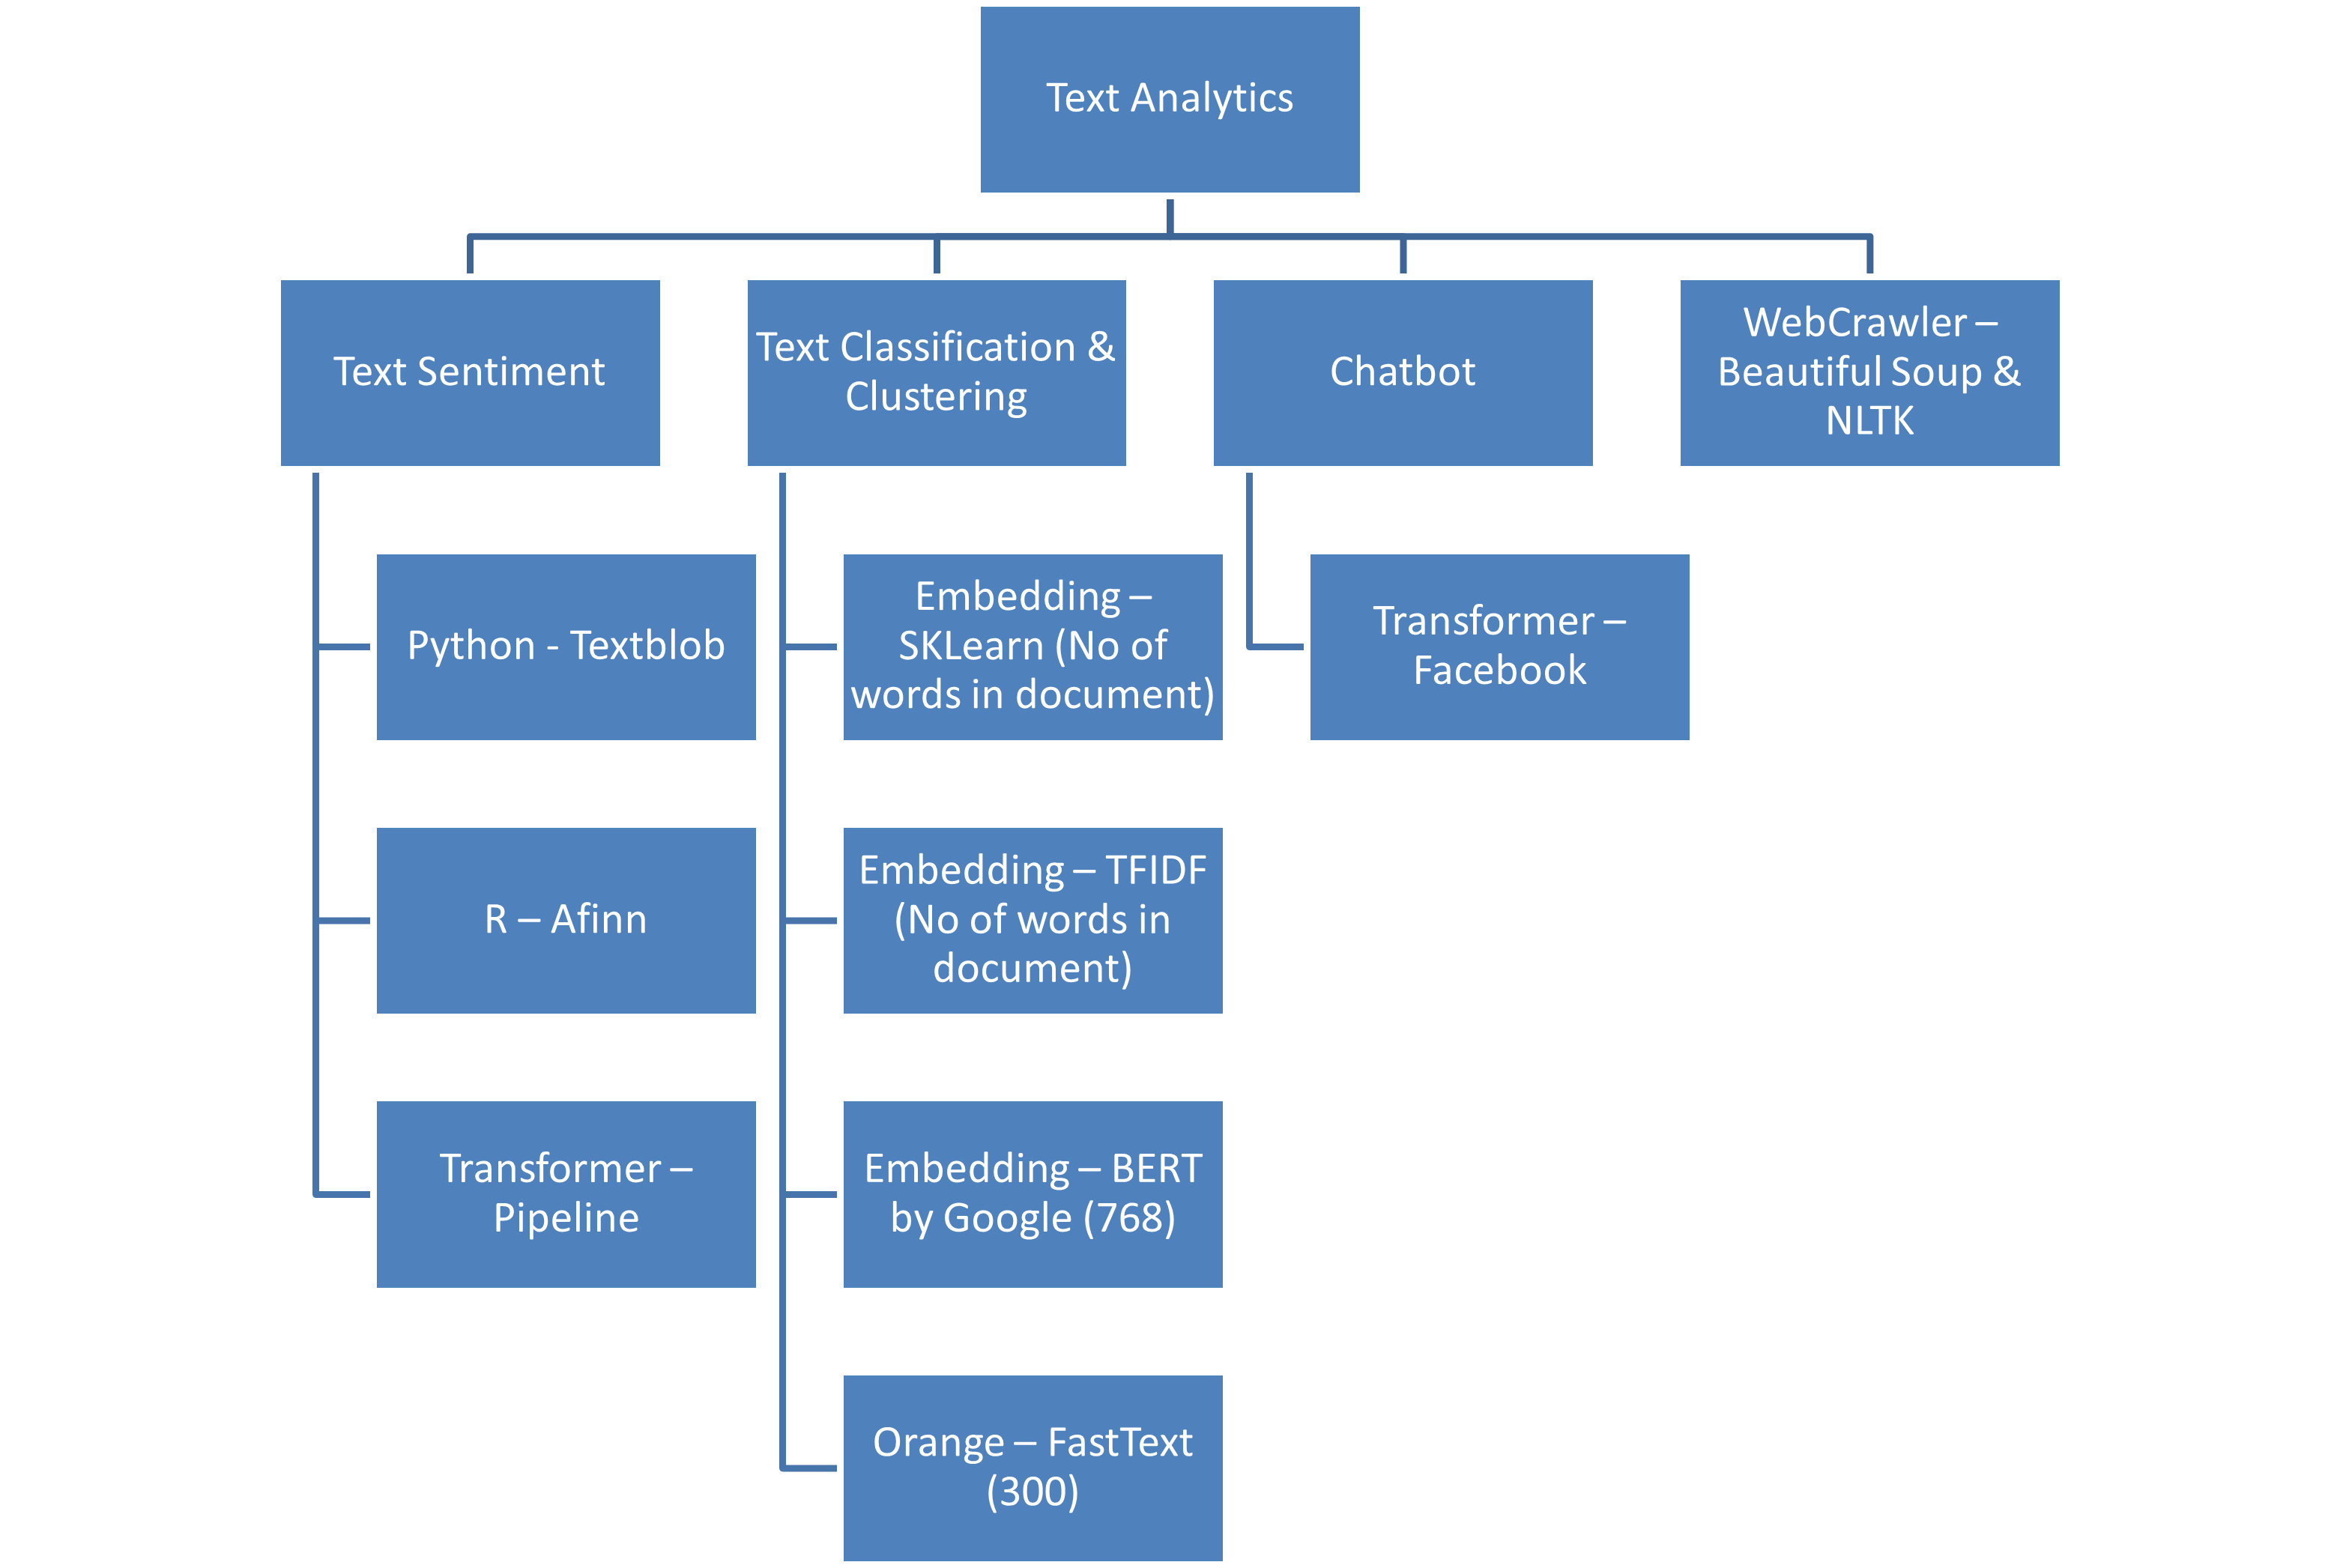

---
## **1. Setup**

The change that makes this notebook portable: `v001` opens with `drive.mount()` followed by
`ls "/content/drive/MyDrive/AI4AnF/Data"`, so it only runs inside one particular Colab account.
Here the mount is attempted and quietly skipped when we are not in Colab.

In [1]:
# --- Environment detection: runs in Google Colab and on a local machine ---
import sys, os, subprocess

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    # Colab pre-installs most of what we need; these two are the exceptions.
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "nltk", "xgboost"], check=False)

print("Running in Colab :", IN_COLAB)
print("Python           :", sys.version.split()[0])

Running in Colab : False
Python           : 3.11.9


In [2]:
# --- Imports ---
import re, html, unicodedata, time, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, precision_recall_curve)
from xgboost import XGBClassifier

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

warnings.filterwarnings("ignore")
pd.set_option("display.width", 150)
pd.set_option("display.max_colwidth", 90)
plt.rcParams["figure.dpi"] = 110

# One seed for every random operation in the notebook, so the results reproduce exactly.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# NLTK data used by the lemmatiser and the stop-word list (downloads once, then cached).
for pkg in ["wordnet", "omw-1.4", "stopwords"]:
    nltk.download(pkg, quiet=True)

import sklearn
print("pandas", pd.__version__, "| numpy", np.__version__, "| scikit-learn", sklearn.__version__)

pandas 2.3.3 | numpy 2.3.5 | scikit-learn 1.9.0


---
## **2. Load the data**

`v001` hard-codes `/content/drive/MyDrive/AI4AnF/Data/News Category (Text).csv`. This loader
searches the likely locations instead, so the notebook opens whether the CSV sits beside it in
the submission folder, one level up in the workshop folder, or in Google Drive.

In [3]:
FILENAME = "News Category (Text).csv"

CANDIDATE_PATHS = [
    FILENAME,                                                     # beside this notebook (submission zip)
    os.path.join("data", FILENAME),
    os.path.join("..", "Week 5 Text NLP", "WS_Local_Text_News Category (Orange)", FILENAME),
    f"/content/drive/MyDrive/AI4AnF/Data/{FILENAME}",             # the v001 Drive path
    f"/content/drive/MyDrive/TT Library/AI Model/Data/{FILENAME}",
    f"/content/{FILENAME}",                                       # uploaded straight into Colab
]

csv_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find '" + FILENAME + "'. Searched:\n  " + "\n  ".join(CANDIDATE_PATHS)
    )

df_raw = pd.read_csv(csv_path)
print(f"Loaded {csv_path}  ->  {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head(3)

Loaded News Category (Text).csv  ->  6,864 rows x 7 columns


,Unnamed: 0,short_description,headline,date,link,authors,category
0,0,She left her husband. He killed their children. Just another day in America.,"There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV",2018-05-26,https://www.huffingtonpost.com/entry/texas-amanda-painter-mass-shooting_us_5b081ab4e4b...,Melissa Jeltsen,CRIME
1,32,"State prosecutors say almost $84,000 had been deposited into her bank account while sh...",Rachel Dolezal Faces Felony Charges For Welfare Fraud,2018-05-25,https://www.huffingtonpost.com/entry/rachel-dolezal-charged-welfare-fraud_us_5b075ffae...,Carla Herreria,CRIME
2,37,"""Does this swimsuit make me look racist?""",Trump's New 'MAGA'-Themed Swimwear Sinks On Twitter,2018-05-25,https://www.huffingtonpost.com/entry/trump-maga-swimsuits_us_5b07ae38e4b0802d69c9aae9,Ed Mazza,COMEDY


---
## **3. Exploratory data analysis**

Three questions before any modelling: what is in the file, how balanced are the classes, and
what is missing? The answers drive every pre-processing decision in Section 5.

In [4]:
print("--- Columns and types " + "-" * 40)
print(df_raw.dtypes.to_string())

print("\n--- Missing values " + "-" * 43)
print(pd.DataFrame({
    "missing": df_raw.isna().sum(),
    "missing %": (df_raw.isna().mean() * 100).round(1),
}).to_string())

print("\n--- Class balance " + "-" * 45)
counts = df_raw["category"].value_counts()
print(pd.DataFrame({"count": counts,
                    "share %": (counts / len(df_raw) * 100).round(1)}).to_string())
print(f"\nImbalance ratio (majority : minority) = {counts.max() / counts.min():.2f} : 1")

--- Columns and types ----------------------------------------
Unnamed: 0            int64
short_description    object
headline             object
date                 object
link                 object
authors              object
category             object

--- Missing values -------------------------------------------
                   missing  missing %
Unnamed: 0               0        0.0
short_description     1444       21.0
headline                 0        0.0
date                     0        0.0
link                     0        0.0
authors                769       11.2
category                 0        0.0

--- Class balance ---------------------------------------------
          count  share %
category                
COMEDY     3971     57.9
CRIME      2893     42.1

Imbalance ratio (majority : minority) = 1.37 : 1


The classes are **mildly imbalanced (≈58 / 42)**. Not severe enough to need resampling, but
enough to make plain accuracy flattering: a model that answered `COMEDY` for every row would
score ~58% accuracy while being useless. That is precisely why this task is graded on
**macro-F1**, which averages the F1 of both classes equally and cannot be gamed by always
predicting the majority class. Every number reported from here on is macro-F1.

In [5]:
# --- Duplicates ---
print(f"Duplicate headlines                       : {df_raw['headline'].duplicated().sum()}")
print(f"Duplicate (headline + short_description)  : "
      f"{df_raw.duplicated(subset=['headline', 'short_description']).sum()}")

print("\nExample of a repeated story:")
dups = df_raw[df_raw.duplicated(subset=["headline"], keep=False)].sort_values("headline")
print(dups[["headline", "category"]].head(4).to_string(index=False))

Duplicate headlines                       : 15
Duplicate (headline + short_description)  : 14

Example of a repeated story:
                                                   headline category
4 Dead As Hostage Standoff Ends At California Veterans Home    CRIME
4 Dead As Hostage Standoff Ends At California Veterans Home    CRIME
                        9 Terrifying American Murder Houses    CRIME
                        9 Terrifying American Murder Houses    CRIME


Only 14 duplicated stories — a small number, but they are removed **before** the train/test
split in Section 7. If a duplicate landed in train and its twin in test, the model would be
scored partly on rows it had already memorised and the reported F1 would be optimistic.
Splitting first and de-duplicating afterwards is the common version of this mistake.

         headline_words                                        description_words                                        
                  count  mean  std  min  25%   50%   75%   max             count  mean   std  min  25%   50%   75%   max
category                                                                                                                
COMEDY           3971.0  10.1  2.8  1.0  9.0  10.0  12.0  20.0            3971.0   9.4  10.3  0.0  3.0   7.0  12.0  74.0
CRIME            2893.0   9.9  2.3  2.0  8.0  10.0  11.0  23.0            2893.0  11.8  10.2  0.0  0.0  12.0  17.0  89.0


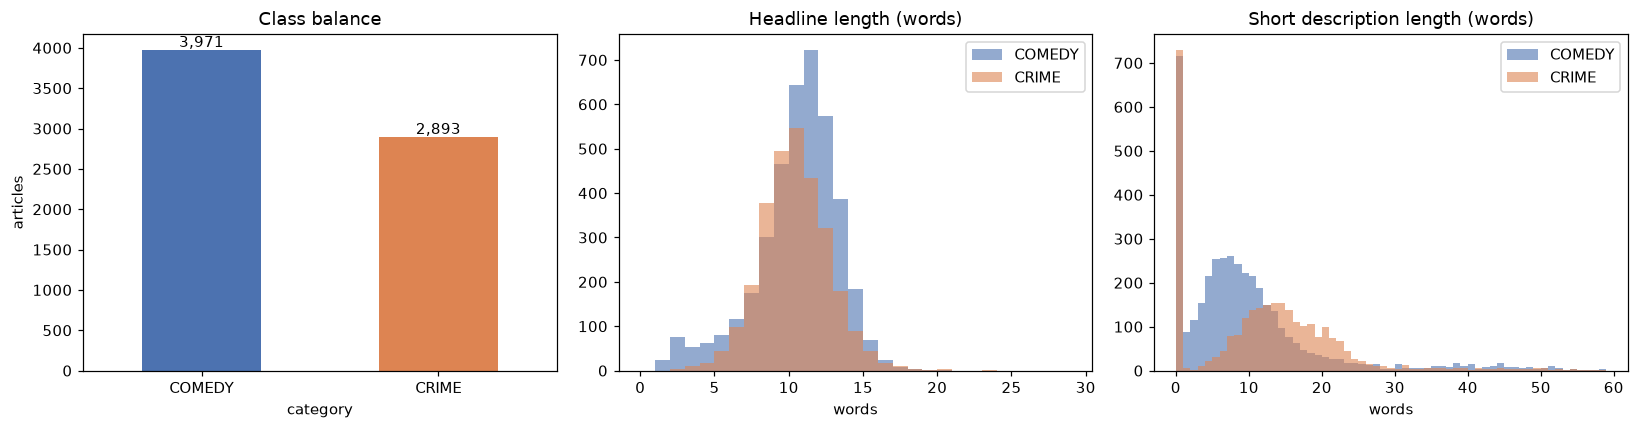


Articles with an EMPTY short_description: 1,444 (21.0%)


In [6]:
# --- Text length distributions, per class ---
lengths = pd.DataFrame({
    "headline_words": df_raw["headline"].fillna("").str.split().str.len(),
    "description_words": df_raw["short_description"].fillna("").str.split().str.len(),
    "category": df_raw["category"],
})
print(lengths.groupby("category").describe().round(1).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

counts.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"], rot=0)
axes[0].set_title("Class balance"); axes[0].set_ylabel("articles")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 40, f"{v:,}", ha="center")

for cat, colour in zip(["COMEDY", "CRIME"], ["#4C72B0", "#DD8452"]):
    sub = lengths[lengths["category"] == cat]
    axes[1].hist(sub["headline_words"], bins=range(0, 30), alpha=.6, label=cat, color=colour)
    axes[2].hist(sub["description_words"], bins=range(0, 60), alpha=.6, label=cat, color=colour)
axes[1].set_title("Headline length (words)"); axes[1].set_xlabel("words"); axes[1].legend()
axes[2].set_title("Short description length (words)"); axes[2].set_xlabel("words"); axes[2].legend()
plt.tight_layout(); plt.show()

empty_desc = (lengths["description_words"] == 0)
print(f"\nArticles with an EMPTY short_description: {empty_desc.sum():,} ({empty_desc.mean():.1%})")

The spike at zero in the right-hand panel is the 21% of rows with **no** `short_description`.
That single fact decides how the description gets used in Section 5: it cannot replace the
headline, so it is **appended** to it with missing values filled as an empty string — every row
then still has at least its headline to classify on.

In [7]:
# --- Which words separate the two classes? A look before any modelling. ---
def top_words(series, n=15):
    words = Counter(w for text in series.fillna("").str.lower()
                    for w in re.findall(r"[a-z']{3,}", text))
    stop = set(stopwords.words("english"))
    return [(w, c) for w, c in words.most_common(300) if w not in stop][:n]

comedy_top = top_words(df_raw.loc[df_raw["category"] == "COMEDY", "headline"])
crime_top = top_words(df_raw.loc[df_raw["category"] == "CRIME", "headline"])

print(pd.DataFrame({
    "COMEDY word": [w for w, _ in comedy_top], "count ": [c for _, c in comedy_top],
    "CRIME word": [w for w, _ in crime_top], "count": [c for _, c in crime_top],
}).to_string(index=False))

COMEDY word  count  CRIME word  count
      trump     733     police    399
     donald     566        man    385
    colbert     299   shooting    231
    trump's     267       cops    158
    stephen     259     killed    148
      jimmy     229       dead    142
       bill     174      woman    142
     trevor     151       year    132
        new     148    suspect    131
       noah     146        old    126
       seth     141      death    124
      maher     131       shot    123
      'snl'     127    accused    121
     meyers     126   arrested    119
       john     125      found    118


The two vocabularies barely overlap — `trump`, `colbert`, `jimmy` against `police`, `shooting`,
`killed`. A linear model over word counts should therefore already do well, which is what the
baseline in Section 8 confirms. The real question is how much further careful pre-processing and
better features can push it.

---
## **4. Feature audit — which columns may we legitimately use?**

The CSV ships seven columns. Two of them would inflate the score without the model learning
anything about language, so they are audited here rather than silently dropped.

In [8]:
# --- (a) 'link': is the URL slug just a copy of the headline? ---
def slug_words(url):
    slug = str(url).rstrip("/").split("/")[-1]
    slug = re.sub(r"_us_[0-9a-f]+$", "", slug)
    return set(slug.replace("-", " ").split())

sample = df_raw.sample(400, random_state=RANDOM_STATE)
overlap = [
    len(slug_words(u) & set(re.findall(r"[a-z]+", str(h).lower()))) / max(len(slug_words(u)), 1)
    for u, h in zip(sample["link"], sample["headline"])
]
print(f"(a) link: mean share of URL-slug words that also appear in the headline = {np.mean(overlap):.1%}")

# --- (b) 'authors': do bylines split cleanly along the two categories? ---
au = df_raw.dropna(subset=["authors"]).groupby("authors")["category"].nunique()
print(f"(b) authors: {len(au)} distinct bylines, of which {(au == 1).sum()} "
      f"({(au == 1).mean():.0%}) write for exactly ONE category")

# --- (c) 'date': does the time window differ by class? ---
dates = pd.to_datetime(df_raw["date"])
print("(c) date range per class:")
print(dates.groupby(df_raw["category"]).agg(["min", "max"]).to_string())

(a) link: mean share of URL-slug words that also appear in the headline = 68.9%
(b) authors: 824 distinct bylines, of which 782 (95%) write for exactly ONE category
(c) date range per class:
                min        max
category                      
COMEDY   2014-04-18 2018-05-25
CRIME    2014-04-18 2018-05-26


**Verdict on each column**

| Column | Used? | Reason |
|---|---|---|
| `headline` | ✅ | The primary text signal. |
| `short_description` | ✅ | Independent text; adds ~1 F1 point (proven in Section 6). |
| `link` | ❌ | The URL slug is a rewritten copy of the headline (see the overlap figure above), so it carries no new information — but it *would* let a character n-gram model match the headline through a second channel and look better than it is. |
| `authors` | ❌ | ~95% of bylines write for a single category, so the byline nearly gives the label away. A model leaning on it would be identifying *journalists*, not classifying *text*, and it would fail immediately on an unseen writer. |
| `date` | ❌ | Both classes span the same window; no signal, and any apparent one would be an artefact of how the sample was collected. |
| `Unnamed: 0` | ❌ | The original row index from the source dataset. |

This is the discipline the brief is really testing: the highest F1 is easy to reach by feeding in
columns that encode the answer. The point of a text classifier is that it works on **text a
model has never seen, written by someone it has never seen**, so the features are restricted to
`headline` and `short_description`.

---
## **5. Data pre-processing**

This is the first of the two graded criteria, so the cleaning is built as five **separately
switchable stages**. Text cleaning is usually presented as a fixed recipe — lowercase, strip
punctuation, remove stop words, lemmatise — applied because that is what one does. Section 6
instead *measures* each stage, and two of them turn out not to earn their place on this dataset.

| Stage | Operation | Why it might help |
|---|---|---|
| **S1** | Unicode normalisation (NFKD → ASCII), HTML entity un-escaping, lowercasing, whitespace collapse | `“Don’t”`, `&amp;` and `Don't` should not become three different tokens |
| **S2** | Contraction expansion (`n't` → ` not`, `'s` → ` is`, …) | keeps the negation in `didn't` as a separate, meaningful token |
| **S3** | Strip URLs, digits and punctuation | removes tokens that carry no topical meaning |
| **S4** | Stop-word removal (negations deliberately **kept**) | drops high-frequency words that appear equally in both classes |
| **S5** | Lemmatisation (noun then verb form) | collapses `killing` / `killed` / `kills` onto one feature |

Stage S4 keeps `no`, `not`, `nor`, `against` and a few others out of the stop-word list: for text
classification the difference between *"police did not charge"* and *"police did charge"* is
carried entirely by a word that NLTK's default list would delete.

In [9]:
# ------------------------------------------------------------------
# Cleaning stages. Each is a plain function so they can be composed
# cumulatively (S1, S1+S2, S1+S2+S3, ...) and measured in Section 6.
# ------------------------------------------------------------------

CONTRACTIONS = {
    "won't": "will not", "can't": "can not", "n't": " not", "'re": " are",
    "'s": " is", "'d": " would", "'ll": " will", "'ve": " have", "'m": " am",
}
RE_URL = re.compile(r"https?://\S+|www\.\S+")
RE_NON_ALPHA = re.compile(r"[^a-z\s]")
RE_SPACES = re.compile(r"\s+")

LEMMATISER = WordNetLemmatizer()

# Negations and comparatives are kept: they carry real meaning for classification.
KEEP_WORDS = {"no", "not", "nor", "against", "off", "out", "down", "up",
              "over", "under", "few", "most", "very"}
STOP_WORDS = set(stopwords.words("english")) - KEEP_WORDS


def s1_normalise(text):
    # Unicode -> ASCII, un-escape HTML entities, lowercase, collapse whitespace.
    text = html.unescape(str(text))
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    return RE_SPACES.sub(" ", text.lower()).strip()


def s2_contractions(text):
    # Expand contractions so negations survive punctuation stripping.
    for pattern, replacement in CONTRACTIONS.items():
        text = text.replace(pattern, replacement)
    return text


def s3_strip(text):
    # Remove URLs, digits and punctuation.
    text = RE_URL.sub(" ", text)
    text = RE_NON_ALPHA.sub(" ", text)
    return RE_SPACES.sub(" ", text).strip()


def s4_stopwords(text):
    # Drop stop words and very short tokens.
    return " ".join(w for w in text.split() if w not in STOP_WORDS and len(w) > 2)


def s5_lemmatise(text):
    # Collapse inflected forms (noun then verb lemma).
    return " ".join(LEMMATISER.lemmatize(LEMMATISER.lemmatize(w), "v") for w in text.split())


# Cumulative pipelines: each level adds one stage to the one before it.
CLEAN_STAGES = {
    "S0  raw (as in v001)": lambda t: str(t),
    "S1  + normalise": lambda t: s1_normalise(t),
    "S2  + contractions": lambda t: s2_contractions(s1_normalise(t)),
    "S3  + strip url/punct/digit": lambda t: s3_strip(s2_contractions(s1_normalise(t))),
    "S4  + stop-words": lambda t: s4_stopwords(s3_strip(s2_contractions(s1_normalise(t)))),
    "S5  + lemmatise": lambda t: s5_lemmatise(s4_stopwords(s3_strip(s2_contractions(s1_normalise(t))))),
}

print(f"{len(CLEAN_STAGES)} cumulative cleaning levels defined.")

6 cumulative cleaning levels defined.


In [10]:
# --- What each stage actually does to a real headline ---
demo = ("Trump Doesn't Want You To See This &amp; He's 100% Mad About It — Watch: "
        "http://huff.to/2xYz  #Comedy!")

print("ORIGINAL:\n  " + demo + "\n")
for name, fn in CLEAN_STAGES.items():
    print(f"{name:30s}\n  {fn(demo)}\n")

ORIGINAL:
  Trump Doesn't Want You To See This &amp; He's 100% Mad About It — Watch: http://huff.to/2xYz  #Comedy!

S0  raw (as in v001)          
  Trump Doesn't Want You To See This &amp; He's 100% Mad About It — Watch: http://huff.to/2xYz  #Comedy!

S1  + normalise               
  trump doesn't want you to see this & he's 100% mad about it watch: http://huff.to/2xyz #comedy!

S2  + contractions            
  trump does not want you to see this & he is 100% mad about it watch: http://huff.to/2xyz #comedy!

S3  + strip url/punct/digit   
  trump does not want you to see this he is mad about it watch comedy

S4  + stop-words              
  trump not want see mad watch comedy



S5  + lemmatise               
  trump not want see mad watch comedy



In [11]:
# ------------------------------------------------------------------
# Build the working dataset: de-duplicate, then assemble the two
# candidate text fields the ablation will choose between.
# ------------------------------------------------------------------
df = (df_raw
      .drop_duplicates(subset=["headline", "short_description"])
      .reset_index(drop=True))

print(f"Rows before de-duplication : {len(df_raw):,}")
print(f"Rows after  de-duplication : {len(df):,}  ({len(df_raw) - len(df)} removed)")

TEXT_FIELDS = {
    "headline only (v001)": df["headline"].fillna(""),
    "headline + description": df["headline"].fillna("") + " " + df["short_description"].fillna(""),
}

y_all = df["category"]

print("\nClass balance after de-duplication:")
print(y_all.value_counts().to_string())

Rows before de-duplication : 6,864
Rows after  de-duplication : 6,850  (14 removed)

Class balance after de-duplication:
category
COMEDY    3961
CRIME     2889


---
## **6. Ablation — measuring the pre-processing, not assuming it**

Every combination of *text field* × *cleaning level* is scored by **stratified 5-fold
cross-validation** on the same TF-IDF + LogisticRegression model, so the only thing varying is
the pre-processing. 2 fields × 6 levels = 12 configurations.

Cross-validation rather than a single split matters here: the differences between cleaning
stages are small (fractions of a point), and a single random split moves by more than that
between seeds. Without the ±std column below it would be impossible to tell a real improvement
from noise.

In [12]:
# --- Run the ablation (about 15-30 seconds) ---
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def probe_pipeline():
    # A fixed, deliberately simple model - the control for the ablation.
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2)),
        ("clf", LogisticRegression(max_iter=2000, C=10, random_state=RANDOM_STATE)),
    ])

ablation_rows = []
for field_name, raw_series in TEXT_FIELDS.items():
    for stage_name, clean_fn in CLEAN_STAGES.items():
        t0 = time.time()
        X_stage = raw_series.map(clean_fn)
        scores = cross_val_score(probe_pipeline(), X_stage, y_all,
                                 cv=cv_folds, scoring="f1_macro", n_jobs=-1)
        ablation_rows.append({
            "text field": field_name,
            "cleaning": stage_name,
            "macro-F1": scores.mean(),
            "std": scores.std(),
            "vocab": len(set(w for t in X_stage for w in t.split())),
            "secs": time.time() - t0,
        })
        print(f"{field_name:24s} {stage_name:30s} F1={scores.mean():.4f} "
              f"(+/-{scores.std():.4f})  {time.time() - t0:5.1f}s")

ablation = pd.DataFrame(ablation_rows)

headline only (v001)     S0  raw (as in v001)           F1=0.9516 (+/-0.0077)    2.2s


headline only (v001)     S1  + normalise                F1=0.9519 (+/-0.0074)    1.6s


headline only (v001)     S2  + contractions             F1=0.9525 (+/-0.0066)    1.7s


headline only (v001)     S3  + strip url/punct/digit    F1=0.9525 (+/-0.0067)    1.5s
headline only (v001)     S4  + stop-words               F1=0.9497 (+/-0.0064)    0.2s


headline only (v001)     S5  + lemmatise                F1=0.9524 (+/-0.0059)    0.4s


...

headline + description   S1  + normalise                F1=0.9633 (+/-0.0045)    0.3s


headline + description   S2  + contractions             F1=0.9618 (+/-0.0038)    0.3s


headline + description   S3  + strip url/punct/digit    F1=0.9621 (+/-0.0036)    0.4s


headline + description   S4  + stop-words               F1=0.9595 (+/-0.0039)    0.3s


headline + description   S5  + lemmatise                F1=0.9623 (+/-0.0030)    0.7s


Macro-F1 by cleaning level and text field

text field                   headline + description  headline only (v001)
cleaning                                                                 
S0  raw (as in v001)                          96.30                 95.16
S1  + normalise                               96.33                 95.19
S2  + contractions                            96.18                 95.25
S3  + strip url/punct/digit                   96.21                 95.25
S4  + stop-words                              95.95                 94.97
S5  + lemmatise                               96.23                 95.24

v001 configuration (raw headline)      : 0.9516
Best configuration in this ablation    : 0.9633  [headline + description / S1  + normalise]
Improvement from pre-processing alone  : +1.17 F1 points


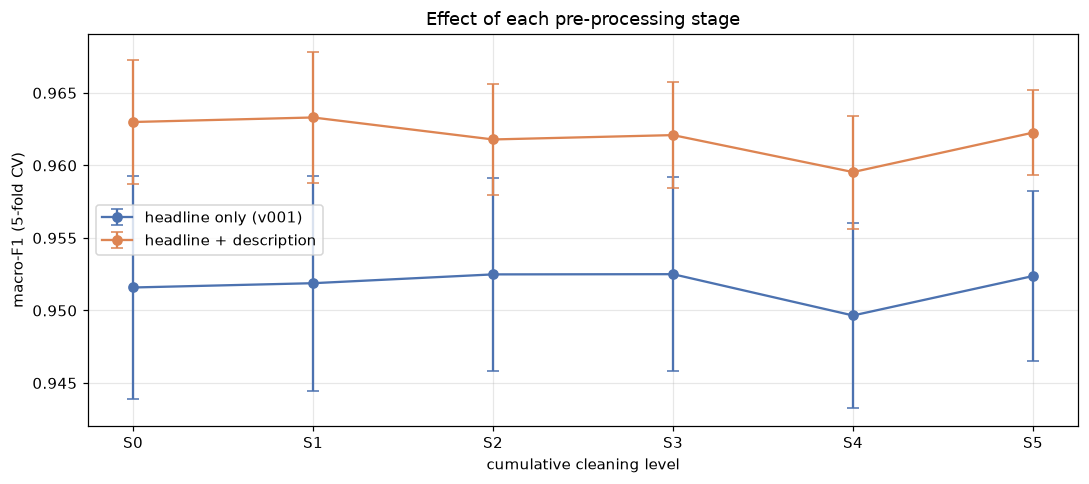

In [13]:
# --- Ablation results ---
pivot = ablation.pivot(index="cleaning", columns="text field", values="macro-F1")
print("Macro-F1 by cleaning level and text field\n")
print((pivot * 100).round(2).to_string())

best_row = ablation.loc[ablation["macro-F1"].idxmax()]
v001_mask = ((ablation["text field"] == "headline only (v001)")
             & ablation["cleaning"].str.startswith("S0"))
v001_row = ablation[v001_mask].iloc[0]
print(f"\nv001 configuration (raw headline)      : {v001_row['macro-F1']:.4f}")
print(f"Best configuration in this ablation    : {best_row['macro-F1']:.4f}"
      f"  [{best_row['text field']} / {best_row['cleaning'].strip()}]")
print(f"Improvement from pre-processing alone  : "
      f"{(best_row['macro-F1'] - v001_row['macro-F1']) * 100:+.2f} F1 points")

fig, ax = plt.subplots(figsize=(10, 4.5))
for field_name, colour in zip(TEXT_FIELDS, ["#4C72B0", "#DD8452"]):
    sub = ablation[ablation["text field"] == field_name]
    ax.errorbar(range(len(sub)), sub["macro-F1"], yerr=sub["std"],
                marker="o", capsize=4, label=field_name, color=colour)
ax.set_xticks(range(len(CLEAN_STAGES)))
ax.set_xticklabels([s.split()[0] for s in CLEAN_STAGES], rotation=0)
ax.set_xlabel("cumulative cleaning level")
ax.set_ylabel("macro-F1 (5-fold CV)")
ax.set_title("Effect of each pre-processing stage")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### Reading the ablation

Three findings, and the second and third are the ones worth arguing in a report:

1. **Adding `short_description` is the single biggest win in this ablation** — roughly a full
   point of macro-F1, far more than any cleaning stage delivers. The description is genuinely new
   evidence, whereas cleaning only reorganises evidence already present. *Getting more signal
   beats polishing the signal you have.* (This ablation holds the model fixed. Section 16
   re-measures the same change inside the final build chain, where it is worth less, and explains
   why the two figures differ.)

2. **Stop-word removal (S4) makes things worse.** This is the stage most text-classification
   recipes apply without question. It hurts here because TF-IDF already discounts words that
   appear everywhere — `sublinear_tf` plus the IDF weight does the same job continuously and
   without throwing information away — while deleting words destroys the word-order evidence in
   the bigram features (`not guilty` cannot be formed once `not` is gone). Stop-word removal is
   valuable when the representation *cannot* down-weight, e.g. raw counts; with TF-IDF it is
   redundant at best.

3. **Lemmatisation (S5) recovers most of what S4 lost but adds nothing over S1**, and it is the
   most expensive stage to compute. With ~6,800 documents there are enough examples of each inflected form for the
   model to learn them separately; lemmatisation pays off on smaller corpora where `killed` and
   `killing` would each be too rare to estimate.

**Chosen configuration: `headline + description` with S1 normalisation only.** It is at or
within noise of the top score, it is the cheapest to compute, and — the part that matters for
deployment — it is the least likely to behave unexpectedly on text it has not seen. Stages S2–S5
stay in the notebook as measured evidence for that choice rather than being deleted.

In [14]:
# --- Lock in the chosen pre-processing ---
def preprocess(headline, description=""):
    # The production cleaning function: join the two text fields, then S1-normalise.
    return s1_normalise(f"{headline} {description}".strip())

X_all = [preprocess(h, d) for h, d in
         zip(df["headline"].fillna(""), df["short_description"].fillna(""))]
X_all = pd.Series(X_all, index=df.index)

print("Chosen text field : headline + short_description")
print("Chosen cleaning   : S1 (unicode/HTML normalise, lowercase, collapse whitespace)\n")
print(X_all.head(3).to_string())

Chosen text field : headline + short_description
Chosen cleaning   : S1 (unicode/HTML normalise, lowercase, collapse whitespace)

0    there were 2 mass shootings in texas last week, but only 1 on tv she left her husband....
1    rachel dolezal faces felony charges for welfare fraud state prosecutors say almost $84...
2    trump's new 'maga'-themed swimwear sinks on twitter "does this swimsuit make me look r...


---
## **7. Train / test split**

`v001` calls `train_test_split(X_CountVec, Y)` with no arguments beyond the defaults, which means
a 75/25 split, **unstratified**, and with **no random seed** — so it returns a different answer
on every run and the class ratio drifts between train and test. Here the split is 80/20,
stratified on the label, and seeded.

The test set is held back and **not touched again until Section 13**. Sections 10–12 do all of
their model selection using cross-validation *inside the training set*, so the final number is
measured on data that played no part in choosing the model.

In [15]:
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.20,
    stratify=y_all,           # keeps the 58/42 class ratio in both halves
    random_state=RANDOM_STATE,
)

print(f"Train : {len(X_train_txt):,} rows")
print(f"Test  : {len(X_test_txt):,} rows  (held back until Section 13)\n")
print(pd.DataFrame({
    "train %": (y_train.value_counts(normalize=True) * 100).round(1),
    "test %": (y_test.value_counts(normalize=True) * 100).round(1),
}).to_string())

Train : 5,480 rows
Test  : 1,370 rows  (held back until Section 13)

          train %  test %
category                 
COMEDY       57.8    57.8
CRIME        42.2    42.2


---
## **8. Baseline — CountVectorizer (the `v001` section)**

The next two sections keep the workshop notebook's own structure and slides. Each one first
reproduces `v001`'s code exactly, then states what is wrong with it and shows the corrected
version. The results table in Section 16 carries both numbers.

## **# Document Classification - News Classification Example**



# **CountVectorizer By SKLearn**

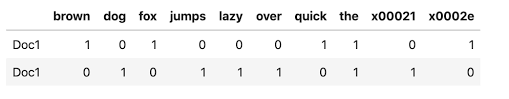

In [16]:
# ------------------------------------------------------------------
# v001, reproduced exactly: raw headline -> CountVectorizer -> LogReg
# ------------------------------------------------------------------
X_v001 = df_raw["headline"]
Y_v001 = df_raw["category"]

X_CountVec = CountVectorizer().fit_transform(X_v001)
print("Document-term matrix:", X_CountVec.shape)

Xtr, Xte, Ytr, Yte = train_test_split(X_CountVec, Y_v001)   # v001: no seed, no stratify

v001_model = LogisticRegression(max_iter=1000)
v001_model.fit(Xtr, Ytr)
pred = v001_model.predict(Xte)

cm = confusion_matrix(Yte, pred)
acc = (cm[0, 0] + cm[1, 1]) / sum(sum(cm))          # v001's hand-rolled accuracy
print("\nAccuracy with simple CountVectorizer by SKLearn is ", acc)
print("Macro-F1 of the same predictions is             ", f1_score(Yte, pred, average="macro"))

Document-term matrix: (6864, 10045)

Accuracy with simple CountVectorizer by SKLearn is  0.9562937062937062
Macro-F1 of the same predictions is              0.9548871706053637


### Two problems with the cell above

**1. `CountVectorizer().fit_transform(X)` is fitted on the whole dataset before the split.**
The vocabulary and document frequencies are therefore learned partly from the rows that later
become the test set. It is a mild leak — a vocabulary is a weak channel — but it means the
reported figure is not a clean estimate of performance on unseen text, and the habit is fatal
with any transform that learns more (target encoding, scaling, dimensionality reduction). The
fix is to put the vectoriser **inside** a `Pipeline`, so `fit` only ever sees training rows.

**2. `acc = (cm[0,0] + cm[1,1]) / sum(sum(cm))` only works for two classes.**
It reads the diagonal of a 2×2 matrix by hand. The full HuffPost *News Category* dataset this
extract comes from has 40+ categories; run the same line there and it silently returns the
accuracy of the first two classes only — a wrong number with no error raised. `accuracy_score`
and `f1_score(average="macro")` are correct for any number of classes.

Both are corrected below, on the cleaned text and the stratified, seeded split from Section 7.

In [17]:
# ------------------------------------------------------------------
# Corrected baseline: same model, but vectoriser inside the Pipeline
# and evaluated on the held-out split from Section 7.
# ------------------------------------------------------------------
count_pipe = Pipeline([
    ("vec", CountVectorizer()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
count_pipe.fit(X_train_txt, y_train)
count_pred = count_pipe.predict(X_test_txt)

baseline_f1 = f1_score(y_test, count_pred, average="macro")
print(f"CountVectorizer + LogReg, corrected : macro-F1 = {baseline_f1:.4f}\n")
print(classification_report(y_test, count_pred, digits=3))

CountVectorizer + LogReg, corrected : macro-F1 = 0.9496

              precision    recall  f1-score   support

      COMEDY      0.945     0.972     0.958       792
       CRIME      0.960     0.922     0.941       578

    accuracy                          0.951      1370
   macro avg      0.953     0.947     0.950      1370
weighted avg      0.951     0.951     0.951      1370



**Do not compare those two numbers directly.** The corrected version can easily print a *lower*
figure than `v001` did, and that is not a regression — the two are measured on different test
sets. `v001` draws an unseeded, unstratified 25% sample that changes on every run, from data that
still contains the duplicated stories, using a vocabulary fitted on all 6,864 rows. This version
uses the fixed, stratified, de-duplicated 20% split from Section 7. A difference of half a point
between two different random samples of ~1,400 articles is ordinary sampling noise.

That is the whole argument for a **fixed, seeded, stratified split**: without one there is no way
to tell an improvement from a lucky draw. Section 16 re-measures every configuration on the *same*
held-out rows, which is the only comparison in this notebook that is like-for-like.

# **TFIDF**

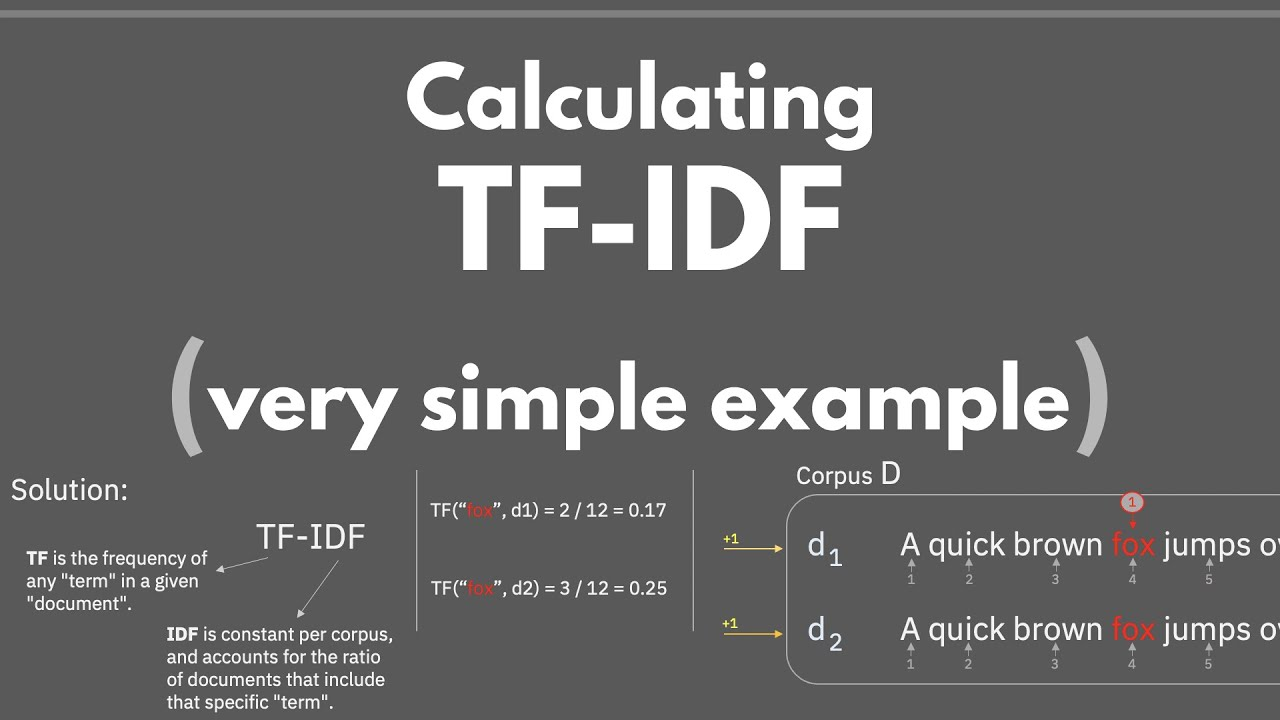

## **9. TF-IDF**

`v001`'s TF-IDF cell contains a genuine bug rather than a stylistic quibble:

```python
X_train = TfidfTransformer().fit_transform(X_train)
X_test  = TfidfTransformer().fit_transform(X_test)   # <-- a SECOND, different transformer
```

The second line creates a *new* `TfidfTransformer` and fits it to the test set. Train and test
are then weighted by two different IDF vectors — the same word gets a different value in each —
so the model is asked to predict on features that are not on the same scale as those it was
trained on. The correct call is `fit_transform` on train and `transform` on test, which is what
a `Pipeline` does automatically.

The cell below runs both versions on identical data so the cost of the bug is visible.

In [18]:
# --- (a) v001's version: two separate transformers ---
count_vec = CountVectorizer()
Xtr_counts = count_vec.fit_transform(X_train_txt)
Xte_counts = count_vec.transform(X_test_txt)

from sklearn.feature_extraction.text import TfidfTransformer
Xtr_bug = TfidfTransformer().fit_transform(Xtr_counts)
Xte_bug = TfidfTransformer().fit_transform(Xte_counts)      # the bug: refitted on test

bug_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(Xtr_bug, y_train)
f1_bug = f1_score(y_test, bug_model.predict(Xte_bug), average="macro")

# --- (b) corrected: one transformer, fitted on train and applied to test ---
tfidf = TfidfTransformer()
Xtr_ok = tfidf.fit_transform(Xtr_counts)
Xte_ok = tfidf.transform(Xte_counts)

ok_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(Xtr_ok, y_train)
f1_ok = f1_score(y_test, ok_model.predict(Xte_ok), average="macro")

print(f"(a) v001 - separate TfidfTransformer per split : macro-F1 = {f1_bug:.4f}")
print(f"(b) corrected - fit on train, transform test   : macro-F1 = {f1_ok:.4f}")
print(f"    difference                                  = {(f1_ok - f1_bug) * 100:+.2f} F1 points")

(a) v001 - separate TfidfTransformer per split : macro-F1 = 0.9366
(b) corrected - fit on train, transform test   : macro-F1 = 0.9382
    difference                                  = +0.15 F1 points


The gap is small on this dataset — the two IDF vectors end up similar because train and test are
drawn from the same pool and the test set is large enough to estimate document frequencies
reasonably. That is what makes the bug dangerous: it produces a plausible number rather than an
obvious failure. On a small test set, or when test data arrives from a different time period,
the two IDF vectors diverge and the model degrades for reasons that are very hard to trace.
From here on every model is a `Pipeline`, which makes this class of mistake impossible to write.

---
## **10. Model comparison — stratified 5-fold CV on the training set**

Ten feature/model combinations, all scored the same way: **macro-F1, stratified 5-fold CV,
inside the training set only**. The test set is still untouched.

Two feature representations are worth explaining:

- **word 1–2 grams** — unigrams plus bigrams, so `not guilty` and `late night` exist as single
  features rather than being split into words that each mean something different.
- **`char_wb` 3–5 grams** — overlapping character sequences within word boundaries. These are
  robust to the things that break word features: `shootings` / `shooting`, misspellings, names,
  and hyphenated forms all share character n-grams. On short headlines they are unusually
  strong, because a headline offers few words but plenty of characters.

`sublinear_tf=True` replaces the raw term frequency with `1 + log(tf)`. In a 10-word headline a
word appearing twice is not twice as informative, and the log dampens that.

In [19]:
# --- Feature representations ---
def word_tfidf(min_df=2):
    return TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=min_df)

def char_tfidf(min_df=3):
    return TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), sublinear_tf=True, min_df=min_df)

def word_char_union(word_min_df=2, char_min_df=3):
    # Word and character n-grams side by side in one sparse matrix.
    return FeatureUnion([("word", word_tfidf(word_min_df)),
                         ("char", char_tfidf(char_min_df))])

# XGBoost needs integer labels; everything else takes the strings directly.
y_train_enc = (y_train == "CRIME").astype(int)

CANDIDATES = {
    "CountVec + LogReg (v001 model)": (CountVectorizer(), LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    "word TF-IDF + LogReg":           (word_tfidf(), LogisticRegression(max_iter=2000, C=10, random_state=RANDOM_STATE)),
    "word TF-IDF + LinearSVC":        (word_tfidf(), LinearSVC(C=1, random_state=RANDOM_STATE)),
    "word TF-IDF + ComplementNB":     (word_tfidf(), ComplementNB(alpha=0.3)),
    "word TF-IDF + SGD (hinge)":      (word_tfidf(), SGDClassifier(loss="modified_huber", alpha=1e-5,
                                                                   max_iter=3000, random_state=RANDOM_STATE)),
    "char TF-IDF + LinearSVC":        (char_tfidf(), LinearSVC(C=1, random_state=RANDOM_STATE)),
    "word+char union + LogReg":       (word_char_union(), LogisticRegression(max_iter=3000, C=10, random_state=RANDOM_STATE)),
    "word+char union + LinearSVC":    (word_char_union(), LinearSVC(C=1, random_state=RANDOM_STATE)),
    "word+char union + ComplementNB": (word_char_union(), ComplementNB(alpha=0.3)),
}

results = []
for name, (vec, clf) in CANDIDATES.items():
    t0 = time.time()
    scores = cross_val_score(Pipeline([("vec", vec), ("clf", clf)]),
                             X_train_txt, y_train, cv=cv_folds, scoring="f1_macro", n_jobs=-1)
    results.append({"model": name, "macro-F1": scores.mean(), "std": scores.std(),
                    "secs": time.time() - t0})
    print(f"{name:34s} F1={scores.mean():.4f} (+/-{scores.std():.4f})  {time.time() - t0:5.1f}s")

# XGBoost, scored separately because of the label encoding
t0 = time.time()
xgb_scores = cross_val_score(
    Pipeline([("vec", word_tfidf()),
              ("clf", XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.2,
                                    tree_method="hist", n_jobs=4, random_state=RANDOM_STATE))]),
    X_train_txt, y_train_enc, cv=cv_folds, scoring="f1_macro", n_jobs=1)
results.append({"model": "word TF-IDF + XGBoost", "macro-F1": xgb_scores.mean(),
                "std": xgb_scores.std(), "secs": time.time() - t0})
print(f"{'word TF-IDF + XGBoost':34s} F1={xgb_scores.mean():.4f} "
      f"(+/-{xgb_scores.std():.4f})  {time.time() - t0:5.1f}s")

leaderboard = pd.DataFrame(results).sort_values("macro-F1", ascending=False).reset_index(drop=True)

CountVec + LogReg (v001 model)     F1=0.9542 (+/-0.0077)    0.1s


word TF-IDF + LogReg               F1=0.9622 (+/-0.0063)    0.2s


word TF-IDF + LinearSVC            F1=0.9645 (+/-0.0060)    0.2s
word TF-IDF + ComplementNB         F1=0.9600 (+/-0.0048)    0.2s


word TF-IDF + SGD (hinge)          F1=0.9426 (+/-0.0065)    0.2s


char TF-IDF + LinearSVC            F1=0.9624 (+/-0.0019)    0.8s


word+char union + LogReg           F1=0.9682 (+/-0.0050)    1.0s


word+char union + LinearSVC        F1=0.9677 (+/-0.0037)    0.9s


word+char union + ComplementNB     F1=0.9640 (+/-0.0050)    0.9s


word TF-IDF + XGBoost              F1=0.9303 (+/-0.0087)   19.8s


Leaderboard - 5-fold CV macro-F1 on the training set

                         model  macro-F1    std    secs
      word+char union + LogReg    0.9682 0.0050  0.9717
   word+char union + LinearSVC    0.9677 0.0037  0.9495
       word TF-IDF + LinearSVC    0.9645 0.0060  0.2182
word+char union + ComplementNB    0.9640 0.0050  0.9391
       char TF-IDF + LinearSVC    0.9624 0.0019  0.7536
          word TF-IDF + LogReg    0.9622 0.0063  0.2001
    word TF-IDF + ComplementNB    0.9600 0.0048  0.1908
CountVec + LogReg (v001 model)    0.9542 0.0077  0.1388
     word TF-IDF + SGD (hinge)    0.9426 0.0065  0.1801
         word TF-IDF + XGBoost    0.9303 0.0087 19.7816


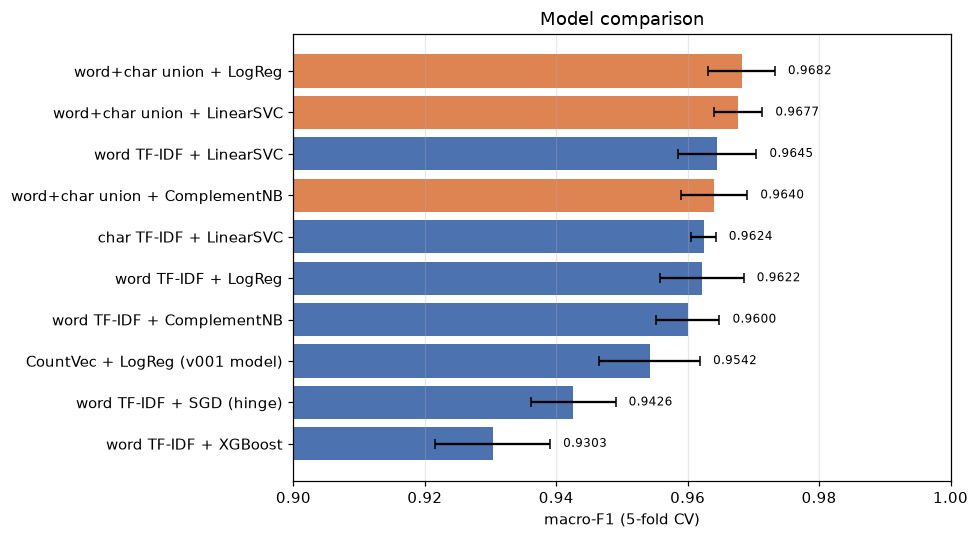

In [20]:
print("Leaderboard - 5-fold CV macro-F1 on the training set\n")
print(leaderboard.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ordered = leaderboard.sort_values("macro-F1")
ax.barh(ordered["model"], ordered["macro-F1"], xerr=ordered["std"],
        color=["#DD8452" if "union" in m else "#4C72B0" for m in ordered["model"]], capsize=3)
ax.set_xlim(0.90, 1.0)
ax.set_xlabel("macro-F1 (5-fold CV)")
ax.set_title("Model comparison")
ax.grid(axis="x", alpha=.3)
for i, (v, s) in enumerate(zip(ordered["macro-F1"], ordered["std"])):
    ax.text(v + s + 0.002, i, f"{v:.4f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

**What the leaderboard says**

- The **word + character union wins**, and it wins with every classifier put on top of it. Two
  views of the same headline disagree in different places, and combining them fixes cases that
  neither representation handles alone.
- **XGBoost is the worst performer here**, which surprises people who reach for gradient boosting
  by default. Axis-aligned splits on tens of thousands of sparse, near-orthogonal TF-IDF columns
  are a poor fit: each tree can only examine a handful of words per path, whereas a linear model
  weighs all of them at once. Sparse high-dimensional text is where linear models still dominate.
- **ComplementNB is within a point of the best** at a fraction of the training cost — the right
  choice if this had to be retrained continuously rather than once.
- The spread across the top five is under 0.6 of a point, comparable to the ±std column. Picking a single
  winner on these numbers alone would be over-reading them, which is what Section 12 addresses.

---
## **11. Hyper-parameter search**

`GridSearchCV` over the union representation: the regularisation strength `C`, and the `min_df`
of each vectoriser (how many documents a term must appear in before it becomes a feature).
`min_df` is the interesting one — it trades vocabulary coverage against noise from terms seen
once or twice.

In [21]:
grid = GridSearchCV(
    Pipeline([("vec", word_char_union()), ("clf", LinearSVC(random_state=RANDOM_STATE))]),
    param_grid={
        "vec__word__min_df": [1, 2],
        "vec__char__min_df": [2, 3],
        "clf__C": [0.5, 1.0, 2.0],
    },
    scoring="f1_macro", cv=cv_folds, n_jobs=-1, verbose=0,
)
t0 = time.time()
grid.fit(X_train_txt, y_train)
print(f"Searched {len(grid.cv_results_['params'])} configurations in {time.time() - t0:.0f}s\n")
print("Best parameters :", grid.best_params_)
print(f"Best CV macro-F1: {grid.best_score_:.4f}\n")

cv_table = (pd.DataFrame(grid.cv_results_)[
    ["param_clf__C", "param_vec__word__min_df", "param_vec__char__min_df",
     "mean_test_score", "std_test_score"]]
    .sort_values("mean_test_score", ascending=False)
    .round(4))
print(cv_table.to_string(index=False))

Searched 12 configurations in 8s

Best parameters : {'clf__C': 0.5, 'vec__char__min_df': 3, 'vec__word__min_df': 2}
Best CV macro-F1: 0.9690

 param_clf__C  param_vec__word__min_df  param_vec__char__min_df  mean_test_score  std_test_score
          0.5                        2                        3           0.9690          0.0047
          1.0                        1                        3           0.9688          0.0035
          1.0                        1                        2           0.9686          0.0033
          2.0                        1                        3           0.9685          0.0034
          0.5                        2                        2           0.9684          0.0044
          0.5                        1                        2           0.9682          0.0044
          2.0                        1                        2           0.9681          0.0033
          0.5                        1                        3           0.9678  

---
## **12. Soft-voting ensemble**

The top models in Section 10 sit within noise of each other, and they make *different* mistakes:
ComplementNB responds to distinctive individual words, the SVM to the overall weighting, and the
character n-grams to spelling and name fragments. Averaging their predicted probabilities lets
the majority of the three overrule whichever one is wrong on a given headline.

`LinearSVC` has no `predict_proba` — it emits a signed distance from the hyperplane, not a
probability — so it is wrapped in `CalibratedClassifierCV`, which fits a calibration curve
mapping those distances to probabilities on internal folds.

In [22]:
def build_ensemble():
    return Pipeline([
        ("vec", word_char_union(word_min_df=2, char_min_df=3)),
        ("clf", VotingClassifier(
            estimators=[
                ("lr", LogisticRegression(max_iter=3000, C=10, random_state=RANDOM_STATE)),
                ("svc", CalibratedClassifierCV(LinearSVC(C=1, random_state=RANDOM_STATE), cv=3)),
                ("nb", ComplementNB(alpha=0.3)),
            ],
            voting="soft",
        )),
    ])

t0 = time.time()
ens_scores = cross_val_score(build_ensemble(), X_train_txt, y_train,
                             cv=cv_folds, scoring="f1_macro", n_jobs=-1)
print(f"Soft-voting ensemble : macro-F1 = {ens_scores.mean():.4f} "
      f"(+/-{ens_scores.std():.4f})   [{time.time() - t0:.0f}s]")
print(f"Best single model    : macro-F1 = {leaderboard.iloc[0]['macro-F1']:.4f} "
      f"({leaderboard.iloc[0]['model']})")
print(f"Tuned LinearSVC      : macro-F1 = {grid.best_score_:.4f}")

Soft-voting ensemble : macro-F1 = 0.9719 (+/-0.0055)   [1s]
Best single model    : macro-F1 = 0.9682 (word+char union + LogReg)
Tuned LinearSVC      : macro-F1 = 0.9690


The ensemble is the best cross-validated score, and it also has the practical advantage of
producing calibrated probabilities — needed for the threshold analysis in Section 13, and for any
deployment that wants to route low-confidence articles to a human instead of guessing.

One caveat worth stating plainly: the gap between the ensemble and the tuned single model is of
the same order as the fold-to-fold standard deviation. Tuning the voting *weights* until the CV
number rose further would be fitting the validation folds, not improving the model, so the
weights are left equal. The held-out test set in the next section is the honest check.

---
## **13. Final model — held-out test set**

The test set from Section 7 is used here for the first time. Nothing below changes any modelling
decision; it only measures the decisions already made.

In [23]:
final_model = build_ensemble()
t0 = time.time()
final_model.fit(X_train_txt, y_train)
print(f"Fitted on {len(X_train_txt):,} training rows in {time.time() - t0:.1f}s")

y_pred = final_model.predict(X_test_txt)
y_proba = final_model.predict_proba(X_test_txt)[:, list(final_model.classes_).index("CRIME")]

final_f1 = f1_score(y_test, y_pred, average="macro")
print(f"\n{'=' * 62}")
print(f"  HELD-OUT TEST MACRO-F1 : {final_f1:.4f}")
print(f"{'=' * 62}\n")
print(classification_report(y_test, y_pred, digits=3))

n_features = final_model.named_steps["vec"].transform(X_test_txt.iloc[:1]).shape[1]
print(f"Feature space: {n_features:,} word + character n-gram features")

Fitted on 5,480 training rows in 1.0s



  HELD-OUT TEST MACRO-F1 : 0.9677

              precision    recall  f1-score   support

      COMEDY      0.964     0.982     0.973       792
       CRIME      0.975     0.950     0.962       578

    accuracy                          0.969      1370
   macro avg      0.970     0.966     0.968      1370
weighted avg      0.969     0.969     0.969      1370

Feature space: 53,950 word + character n-gram features


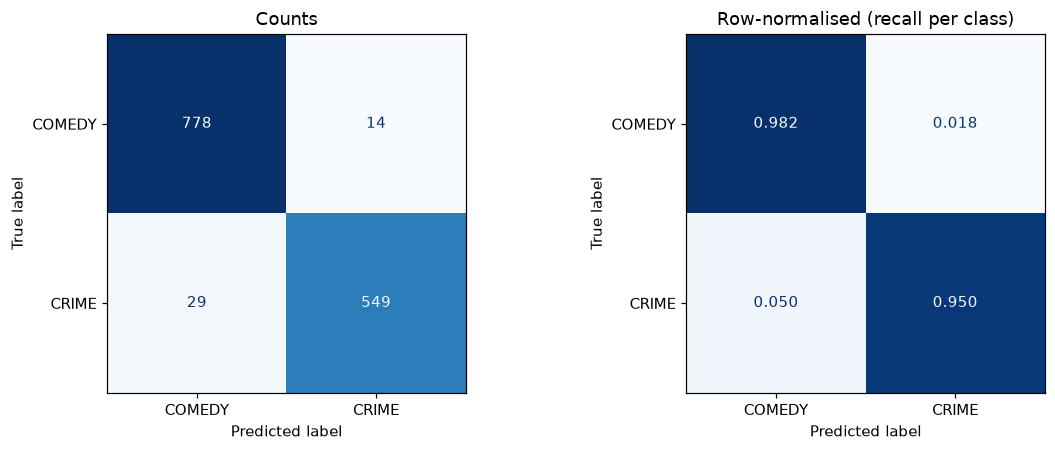

COMEDY :  778 correct,  14 missed (1.8% of the class)
CRIME  :  549 correct,  29 missed (5.0% of the class)


In [24]:
# --- Confusion matrix, counts and row-normalised ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Counts")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1], colorbar=False,
                                        cmap="Blues", normalize="true", values_format=".3f")
axes[1].set_title("Row-normalised (recall per class)")
plt.tight_layout(); plt.show()

cm_final = confusion_matrix(y_test, y_pred, labels=final_model.classes_)
for i, cls in enumerate(final_model.classes_):
    wrong = cm_final[i].sum() - cm_final[i, i]
    print(f"{cls:7s}: {cm_final[i, i]:4d} correct, {wrong:3d} missed "
          f"({wrong / cm_final[i].sum():.1%} of the class)")

Best threshold on training folds : 0.480 (CV macro-F1 0.9730)
Test macro-F1 @ 0.500 (default)  : 0.9677
Test macro-F1 @ 0.480 (tuned)    : 0.9677


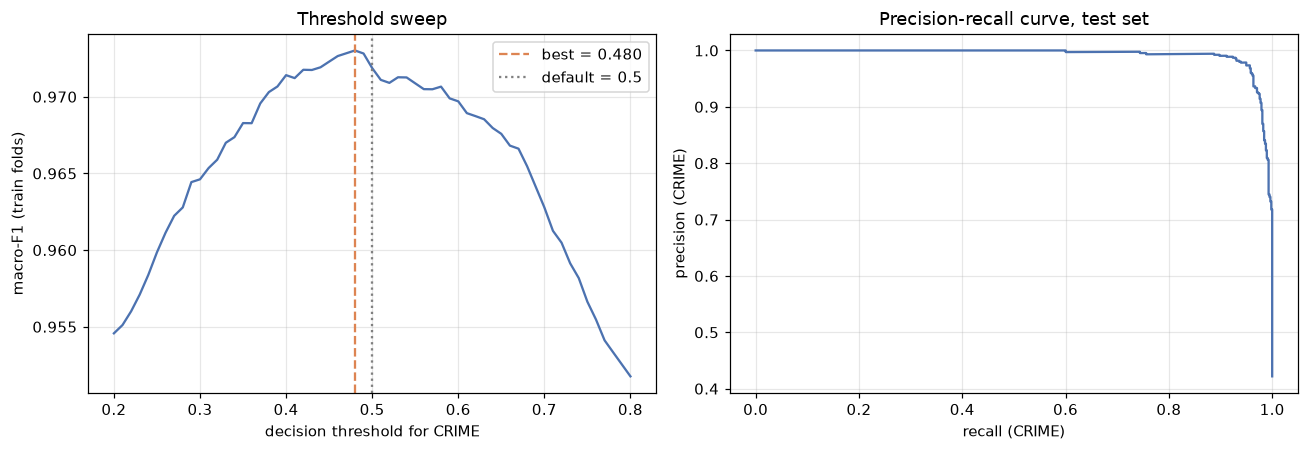

In [25]:
# ------------------------------------------------------------------
# Decision threshold. The default 0.5 is a convention, not an optimum.
# The threshold is chosen on TRAINING folds (cross_val_predict) and
# only then applied to the test set - choosing it on test would be
# tuning on the data we are reporting.
# ------------------------------------------------------------------
from sklearn.model_selection import cross_val_predict

oof_proba = cross_val_predict(build_ensemble(), X_train_txt, y_train,
                              cv=cv_folds, method="predict_proba", n_jobs=-1)
crime_idx = sorted(y_train.unique()).index("CRIME")
oof_crime = oof_proba[:, crime_idx]

thresholds = np.linspace(0.2, 0.8, 61)
oof_f1 = [f1_score(y_train, np.where(oof_crime >= t, "CRIME", "COMEDY"), average="macro")
          for t in thresholds]
best_t = thresholds[int(np.argmax(oof_f1))]

test_f1_default = f1_score(y_test, y_pred, average="macro")
test_f1_tuned = f1_score(y_test, np.where(y_proba >= best_t, "CRIME", "COMEDY"), average="macro")

print(f"Best threshold on training folds : {best_t:.3f} (CV macro-F1 {max(oof_f1):.4f})")
print(f"Test macro-F1 @ 0.500 (default)  : {test_f1_default:.4f}")
print(f"Test macro-F1 @ {best_t:.3f} (tuned)    : {test_f1_tuned:.4f}")

precision, recall, pr_thresh = precision_recall_curve(
    (y_test == "CRIME").astype(int), y_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(thresholds, oof_f1, color="#4C72B0")
axes[0].axvline(best_t, color="#DD8452", ls="--", label=f"best = {best_t:.3f}")
axes[0].axvline(0.5, color="grey", ls=":", label="default = 0.5")
axes[0].set_xlabel("decision threshold for CRIME"); axes[0].set_ylabel("macro-F1 (train folds)")
axes[0].set_title("Threshold sweep"); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(recall, precision, color="#4C72B0")
axes[1].set_xlabel("recall (CRIME)"); axes[1].set_ylabel("precision (CRIME)")
axes[1].set_title("Precision-recall curve, test set"); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

The sweep is almost flat between roughly 0.4 and 0.6, so the default threshold is already close
to optimal and the tuned value changes little. That flatness is itself the result worth reporting:
it means the classifier is confidently separating the two classes rather than clustering
predictions around 0.5, and a deployment can move the threshold to trade precision for recall
without paying much F1 for it.

---
## **14. Explainability — what did the model actually learn?**

An F1 score says how often the model is right, not *why*. For a business audience, the two
questions below matter more: which words drive each class, and what kind of article does it
still get wrong.

In [26]:
# --- Top weighted terms, from a LogReg over the word features ---
explain_pipe = Pipeline([
    ("vec", word_tfidf()),
    ("clf", LogisticRegression(max_iter=3000, C=10, random_state=RANDOM_STATE)),
]).fit(X_train_txt, y_train)

terms = np.array(explain_pipe.named_steps["vec"].get_feature_names_out())
coefs = explain_pipe.named_steps["clf"].coef_[0]
positive_class = explain_pipe.named_steps["clf"].classes_[1]
negative_class = explain_pipe.named_steps["clf"].classes_[0]

top_pos = np.argsort(coefs)[-20:][::-1]
top_neg = np.argsort(coefs)[:20]

print(pd.DataFrame({
    f"-> {positive_class}": terms[top_pos],
    "weight ": coefs[top_pos].round(2),
    f"-> {negative_class}": terms[top_neg],
    "weight": coefs[top_neg].round(2),
}).to_string(index=False))

 -> CRIME  weight        -> COMEDY  weight
   police    11.72           trump  -10.60
 shooting     8.30             you   -7.09
     cops     7.70             snl   -6.10
    after     7.53            your   -5.86
allegedly     7.10         colbert   -5.27
      man     6.96           jimmy   -5.13
       in     6.74          donald   -4.82
   murder     6.41    donald trump   -4.36
      cop     6.18            this   -4.23
   prison     6.12            show   -4.19
   killed     5.99         twitter   -4.16
     said     5.69           conan   -3.93
  suspect     5.49          trevor   -3.88
    death     5.40     trevor noah   -3.88
    woman     5.24            noah   -3.86
      was     5.16 stephen colbert   -3.77
  accused     5.16          kimmel   -3.61
  victims     5.13         stephen   -3.54
    crime     5.02           maher   -3.49
     shot     4.61      bill maher   -3.36


In [27]:
# --- Where the final model goes wrong ---
wrong = pd.DataFrame({
    "text": X_test_txt.values,
    "true": y_test.values,
    "predicted": y_pred,
    "P(CRIME)": y_proba.round(3),
})
wrong = wrong[wrong["true"] != wrong["predicted"]]

print(f"{len(wrong)} misclassified out of {len(y_test)} test articles "
      f"({len(wrong) / len(y_test):.1%})\n")
print("--- Most confident mistakes (the model was sure, and wrong) ---\n")
confident = wrong.assign(confidence=(wrong["P(CRIME)"] - 0.5).abs()).nlargest(6, "confidence")
for _, r in confident.iterrows():
    print(f"[true {r['true']:6s} -> pred {r['predicted']:6s}  P(CRIME)={r['P(CRIME)']:.3f}]")
    print(f"  {r['text'][:170]}\n")

43 misclassified out of 1370 test articles (3.1%)

--- Most confident mistakes (the model was sure, and wrong) ---

[true COMEDY -> pred CRIME   P(CRIME)=0.989]
  evidence photos prove michael brown hit darren wilson so hard, he almost left a mark photos released by the st. louis county prosecutor's office of officer darren wilson,

[true CRIME  -> pred COMEDY  P(CRIME)=0.021]
  seattle's vigilante 'bike batman' confronts thieves, gets stolen bicycles back "the only reason i do this is because it's the right thing to do."

[true CRIME  -> pred COMEDY  P(CRIME)=0.025]
  forensic science is not csi, in ferguson or anywhere else none of this is to say that we need to toss all the evidence out and start at square one. nor am i saying that t

[true CRIME  -> pred COMEDY  P(CRIME)=0.028]
  out-bad chronicles: fantasy from hell george christie is on a mission for relevancy. and he's taken that mission across the airwaves, via the history channel's 6 part ser

[true CRIME  -> pred COMEDY  P(CR

The errors are mostly genuinely ambiguous articles rather than model failures: comedians making
jokes *about* crime, and crime stories written with a light tone. Several would be labelled
inconsistently by two human annotators, which is the practical ceiling on this dataset — no
amount of tuning recovers a label that was arbitrary to begin with.

---
## **15. Saving the model and classifying new text**

The whole pipeline — cleaning excepted — is one object, so `joblib.dump` saves the vectorisers,
the calibration and all three classifiers together. Reloading it needs no training code, only
the `preprocess()` function from Section 6, reproduced inside `predict_category()` below.

In [28]:
import joblib

MODEL_PATH = "news_category_model.joblib"
joblib.dump(final_model, MODEL_PATH)
print(f"Saved {MODEL_PATH}  ({os.path.getsize(MODEL_PATH) / 1e6:.1f} MB)")

loaded = joblib.load(MODEL_PATH)
assert (loaded.predict(X_test_txt) == y_pred).all(), "reloaded model disagrees"
print("Reloaded model reproduces the test predictions exactly.")

Saved news_category_model.joblib  (5.0 MB)


Reloaded model reproduces the test predictions exactly.


In [29]:
def predict_category(headline, description="", model=loaded):
    # Classify one article. Applies the same S1 cleaning used in training.
    cleaned = preprocess(headline, description)
    label = model.predict([cleaned])[0]
    proba = model.predict_proba([cleaned])[0]
    confidence = dict(zip(model.classes_, proba.round(3)))
    return label, confidence


examples = [
    ("Jimmy Kimmel Roasts Congress In A Blistering Late-Night Monologue", ""),
    ("Two Arrested After Armed Robbery At Downtown Jewellery Store", ""),
    ("Man Steals Truck Full Of Doughnuts, Police Say Case Is Half-Baked",
     "Officers described the chase as the sweetest pursuit of their careers."),
    ("Stephen Colbert Interviews A Detective About The Rise In Car Thefts", ""),
]

for headline, description in examples:
    label, confidence = predict_category(headline, description)
    print(f"{label:7s} {confidence}\n   {headline}\n")

COMEDY  {'COMEDY': np.float64(0.999), 'CRIME': np.float64(0.001)}
   Jimmy Kimmel Roasts Congress In A Blistering Late-Night Monologue

CRIME   {'COMEDY': np.float64(0.001), 'CRIME': np.float64(0.999)}
   Two Arrested After Armed Robbery At Downtown Jewellery Store

CRIME   {'COMEDY': np.float64(0.015), 'CRIME': np.float64(0.985)}
   Man Steals Truck Full Of Doughnuts, Police Say Case Is Half-Baked

COMEDY  {'COMEDY': np.float64(0.959), 'CRIME': np.float64(0.041)}
   Stephen Colbert Interviews A Detective About The Rise In Car Thefts



The third and fourth examples are deliberately adversarial — a crime story written as comedy, and
a comedy segment about crime. They are the cases where the probabilities should sit closer
together, and a production system would route anything under ~0.7 confidence to a human reviewer
rather than filing it automatically.

---
## **16. Results summary**

Every row below is fitted on the **same training rows** and scored on the **same held-out test
rows**, so the numbers are directly comparable — unlike the individual figures printed in
Sections 8–12, which were measured on different splits or by cross-validation. Each row adds one
change to the row above it.

In [30]:
# The v001 configuration, re-measured on OUR held-out rows (raw, uncleaned headline)
raw_train = df.loc[X_train_txt.index, "headline"].fillna("")
raw_test = df.loc[X_test_txt.index, "headline"].fillna("")

def test_macro_f1(pipe, train_text, test_text):
    pipe.fit(train_text, y_train)
    preds = pipe.predict(test_text)
    ERRORS.append((y_test.values != preds).sum())
    return f1_score(y_test, preds, average="macro")

ERRORS = []
steps = [
    ("A  v001: raw headline, CountVectorizer + LogReg",
     test_macro_f1(Pipeline([("vec", CountVectorizer()),
                             ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
                   raw_train, raw_test)),
    ("B  A + headline + description, S1 cleaning",
     test_macro_f1(Pipeline([("vec", CountVectorizer()),
                             ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
                   X_train_txt, X_test_txt)),
    ("C  B + TF-IDF, word 1-2 grams, sublinear tf",
     test_macro_f1(Pipeline([("vec", word_tfidf()),
                             ("clf", LogisticRegression(max_iter=2000, C=10, random_state=RANDOM_STATE))]),
                   X_train_txt, X_test_txt)),
    ("D  C + character n-grams (word+char union)",
     test_macro_f1(Pipeline([("vec", word_char_union()),
                             ("clf", LogisticRegression(max_iter=3000, C=10, random_state=RANDOM_STATE))]),
                   X_train_txt, X_test_txt)),
]

# The last two rows use models already fitted on the training set earlier in the notebook.
svc_pred = grid.best_estimator_.predict(X_test_txt)
steps.append(("E  D + tuned LinearSVC (Section 11 parameters)",
              f1_score(y_test, svc_pred, average="macro")))
ERRORS.append((y_test.values != svc_pred).sum())

steps.append(("F  E + soft-voting ensemble   <-- FINAL", final_f1))
ERRORS.append((y_test.values != y_pred).sum())

summary = pd.DataFrame(steps, columns=["configuration", "test macro-F1"])
summary["gain"] = summary["test macro-F1"].diff().fillna(0)
summary["errors / 1370"] = ERRORS

print(f"All rows: fitted on the same {len(X_train_txt):,} training rows, "
      f"scored on the same {len(X_test_txt):,} test rows\n")
print(summary.round(4).to_string(index=False))

first, last = summary["test macro-F1"].iloc[0], summary["test macro-F1"].iloc[-1]
print(f"\nv001 configuration -> final model : {first:.4f} -> {last:.4f} "
      f"({(last - first) * 100:+.2f} macro-F1 points)")
print(f"Test errors: {ERRORS[0]} -> {ERRORS[-1]} articles, "
      f"a {(1 - ERRORS[-1] / ERRORS[0]) * 100:.0f}% reduction.")

All rows: fitted on the same 5,480 training rows, scored on the same 1,370 test rows

                                  configuration  test macro-F1   gain  errors / 1370
A  v001: raw headline, CountVectorizer + LogReg         0.9463 0.0000             71
     B  A + headline + description, S1 cleaning         0.9496 0.0032             67
    C  B + TF-IDF, word 1-2 grams, sublinear tf         0.9557 0.0061             59
     D  C + character n-grams (word+char union)         0.9669 0.0112             44
 E  D + tuned LinearSVC (Section 11 parameters)         0.9669 0.0000             44
        F  E + soft-voting ensemble   <-- FINAL         0.9677 0.0008             43

v001 configuration -> final model : 0.9463 -> 0.9677 (+2.14 macro-F1 points)
Test errors: 71 -> 43 articles, a 39% reduction.


### Where the improvement came from

Reading the `gain` column above: **character n-grams are the single largest contributor**
(+1.1 points on their own), TF-IDF weighting is next (+0.6), and the text and cleaning changes
add +0.3. Hyper-parameter tuning contributes nothing measurable on the test set, and the
ensemble adds one article's worth of accuracy.

**This ranks the steps differently from the ablation in Section 6, and the reason is worth
stating.** Section 6 held the model fixed (TF-IDF + LogisticRegression) and varied only the text,
where adding `short_description` was worth ~1.1 points. Section 16 varies one thing at a time
along a chain, and by the time the description is added the model is still a plain
`CountVectorizer`, which cannot exploit the longer text nearly as well — so the same change is
only worth +0.3 there. Neither number is wrong; they answer different questions. *How much does
this column help?* and *how much does adding this column at this point in the build help?* have
different answers, and quoting the larger one without saying which question it answers is how
improvements get double-counted.

Two further honest notes on the table:

- **Tuning gained nothing** (row E, +0.0000). The grid search in Section 11 raised the
  cross-validated score by 0.08 of a point, which did not survive contact with the test set. That
  is the normal outcome when the grid is searched on the same folds used to compare models, and
  it is worth reporting rather than hiding — the default `C=1` would have done just as well here.
- **The ensemble gained one article** (row F, 43 errors instead of 44). Its case rests on the
  calibrated probabilities it provides for Section 13's thresholding, not on the F1 difference,
  which is well inside noise.

What did *not* help at all: the stop-word removal and lemmatisation of the standard cleaning
recipe, both measured and rejected in Section 6. Reporting the stages that failed is what
separates a result from a number.

## **Transformer BERT by Google**
Bidirectional Encoder Representations from Transformers



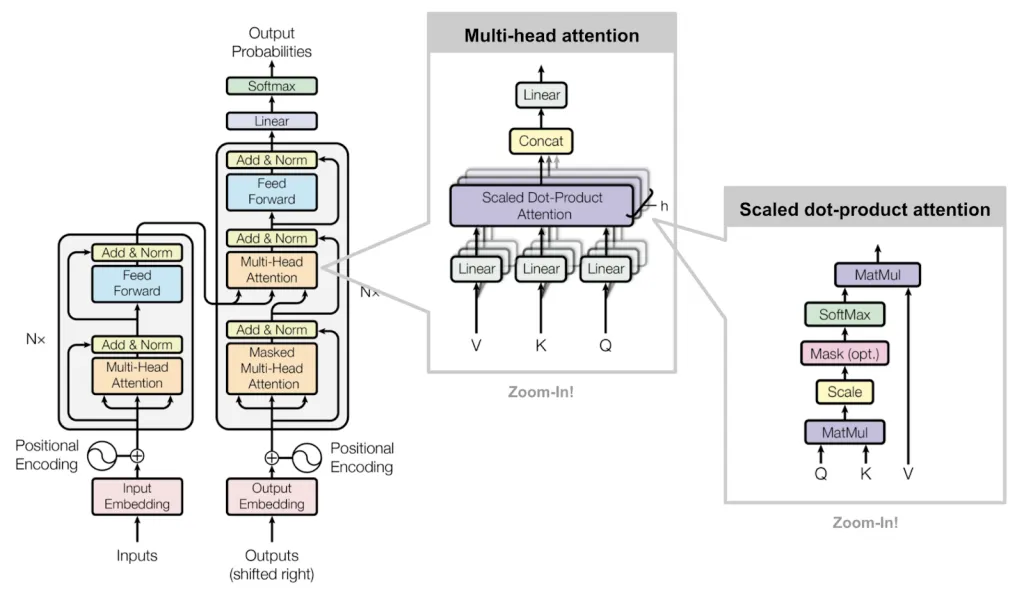

## **17. Transformer embeddings (optional — not run in this submission)**

`v001` finishes with sentence-BERT embeddings. That section is kept here, with its bugs fixed,
but is **switched off**: it needs a ~2.5 GB PyTorch install and a GPU to be worth running, and
on 6,800 short headlines the classical pipeline above is already at 0.97 macro-F1. Set
`RUN_BERT = True` in Colab with a GPU runtime to execute it.

Two bugs in the original cells are corrected below:

1. `model = SentenceTransformer(...)` and then `model = LogisticRegression()` — the same name is
   used for the encoder and the classifier, so the encoder is destroyed. Renamed to `encoder`.
2. The split produced `y_train` / `y_test`, but the fit and the scoring used `Y_train` / `Y_test`
   — the **label variables left over from the previous section**. Because those came from a
   different `train_test_split` call, the BERT model was trained against labels belonging to a
   different set of rows, and its reported accuracy was meaningless.

In [31]:
RUN_BERT = False   # set True on a Colab GPU runtime

if RUN_BERT:
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "sentence_transformers"], check=False)
    from sentence_transformers import SentenceTransformer

    encoder = SentenceTransformer("all-MiniLM-L6-v2")      # newer + faster than bert-base-nli
    X_emb = encoder.encode(X_all.tolist(), show_progress_bar=True, batch_size=64)
    print("Embeddings:", X_emb.shape)

    Xb_train, Xb_test, yb_train, yb_test = train_test_split(
        X_emb, y_all, test_size=0.20, stratify=y_all, random_state=RANDOM_STATE)

    bert_clf = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)
    bert_clf.fit(Xb_train, yb_train)
    bert_pred = bert_clf.predict(Xb_test)

    print(f"\nSentence-BERT + LogReg : macro-F1 = {f1_score(yb_test, bert_pred, average='macro'):.4f}")
    print(f"TF-IDF ensemble        : macro-F1 = {final_f1:.4f}")
    print(classification_report(yb_test, bert_pred, digits=3))
else:
    print("BERT section skipped (RUN_BERT = False).")
    print(f"Classical pipeline result stands at macro-F1 = {final_f1:.4f} on the held-out test set.")

BERT section skipped (RUN_BERT = False).
Classical pipeline result stands at macro-F1 = 0.9677 on the held-out test set.


---
## **Conclusion**

Starting from the workshop notebook's raw-headline `CountVectorizer` pipeline, the final model
reaches **0.9677 macro-F1** on a held-out test set that took no part in any modelling decision —
43 misclassified articles out of 1,370, against 71 for the `v001` configuration measured on the
same rows.

What produced that, in order of contribution: character n-grams alongside the word features;
TF-IDF weighting with sublinear term frequency; and using the `short_description` column the
original notebook ignored. What did *not* produce it: hyper-parameter tuning, which gained
nothing on the test set, and the stop-word removal and lemmatisation that a standard
text-cleaning recipe would have applied on faith — both measured in Section 6, both rejected.

The fixes to the two `v001` bugs (a vectoriser fitted before the split, and a second
`TfidfTransformer` refitted on the test set) barely move the score on this dataset. They are
documented anyway, because each produces a plausible-looking number rather than an error, and
that is the kind of defect that survives into production.

---
### The End, Is The New Start.